# Uncertainty estimation in linear regression, logistic regression, and poisson GLMs

This notebook contains a demo of:

1. **Linear regression** to model linear relationship in synthetic dataset  
2. **Logistic regression** on binary spike train data from a simulated neuron  
3. **Poisson GLM** on spike counts from the same simulated spike-train dataset  

In each case, we will use **bootstrapping** to estimate uncertainty in parameters and visualize the uncertainty in predictions.

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, PoissonRegressor
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (7, 4)

## Bootstrap predicted curves

In [ ]:
def bootstrap_curve(X, y, xgrid, fit_predict_fn, n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y)
    preds = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X[idx]
        yb = y[idx]
        pred = fit_predict_fn(Xb, yb, xgrid)
        preds.append(pred)

    preds = np.asarray(preds)
    lo = np.percentile(preds, 2.5, axis=0)
    med = np.percentile(preds, 50, axis=0)
    hi = np.percentile(preds, 97.5, axis=0)
    return preds, lo, med, hi

## 1. Linear regression

We first use a very simple example where the underlying relationship is actually linear:

$ y = \beta_0 + \beta_1 x + \epsilon $

This makes the linear regression demo clean and easy to interpret before moving on to spike-train data.

In [ ]:
# Simulate linear data
n_lin = 100
x_lin = np.linspace(0, 10, n_lin)
true_intercept = 2
true_slope = 1.5
noise_sd = 5

y_lin_true = true_intercept + true_slope * x_lin
y_lin = y_lin_true + rng.normal(0, noise_sd, size=n_lin)

X_lin = x_lin.reshape(-1, 1)
xgrid_lin = np.linspace(x_lin.min(), x_lin.max(), 200).reshape(-1, 1)

In [ ]:
def fit_predict_linear(X, y, xgrid):
    model = LinearRegression()
    model.fit(X, y)
    return model.predict(xgrid)

# # Fit without bootstrapping
# lin_model = LinearRegression()
# lin_model.fit(X_lin, y_lin)
# lin_preds = lin_model.predict(xgrid_lin)

# Fit with bootstrapping
lin_preds, lin_lo, lin_med, lin_hi = bootstrap_curve(X_lin, y_lin, xgrid_lin, fit_predict_linear, n_boot=500, seed=1)

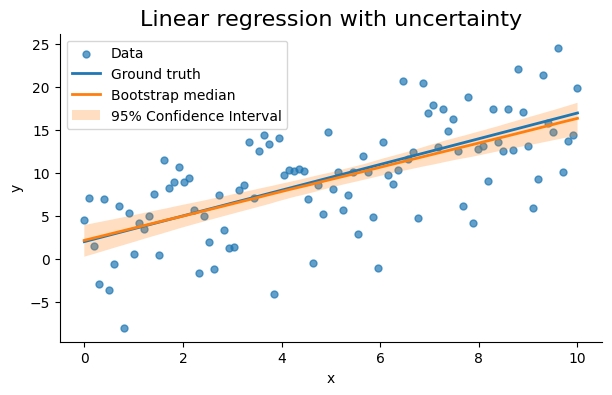

In [ ]:
plt.figure()
plt.scatter(x_lin, y_lin, s=25, alpha=0.7, label='Data')
plt.plot(x_lin, y_lin_true, linewidth=2, label='Ground truth')
plt.plot(xgrid_lin, lin_med, linewidth=2, label='Bootstrap median')
plt.fill_between(xgrid_lin.flatten(), lin_lo, lin_hi, alpha=0.25, label='95% Confidence Interval')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear regression with uncertainty', fontsize=16)
plt.legend()
plt.show()

## 2. Simulate a neural spike-train dataset

Now we switch to a neuron with a time-varying firing rate over repeated trials.

- Time is divided into bins of width `dt`
- On each trial, spikes are generated from a Poisson process
- We use the same simulated neuron for both logistic regression and the Poisson GLM

In [ ]:
# Trial and time settings
n_trials = 150
T = 1
dt = 0.01
t = np.arange(0, T, dt)
n_time = len(t)

# True firing rate function
def true_rate_fn(t):
    bump1 = 15 * np.exp(-0.5 * ((t - 0.3) / 0.1) ** 2)
    bump2 = 10 * np.exp(-0.5 * ((t - 0.7) / 0.2) ** 2)
    baseline = 3
    return baseline + bump1 + bump2
true_rate = true_rate_fn(t)

# trial-to-trial variability
trial_gain = rng.lognormal(mean=0, sigma=0.15, size=n_trials)

# Simulate spike counts in each bin
spike_counts = np.zeros((n_trials, n_time), dtype=int)

for i in range(n_trials):
    lam = trial_gain[i] * true_rate * dt
    spike_counts[i] = rng.poisson(lam)

# Binarize for logistic regression
spike_binary = (spike_counts > 0).astype(int)

# Summary stats
mean_rate_empirical = spike_counts.mean(axis=0) / dt
emp_spike_prob = spike_binary.mean(axis=0)

# Poisson-process probability of at least one spike in a bin
true_spike_prob = 1 - np.exp(-true_rate * dt)

print('spike_counts shape:', spike_counts.shape)
print('Mean firing rate: %.2f Hz' % (spike_counts.mean() / dt))

spike_counts shape: (150, 100)
Mean firing rate: 11.25 Hz


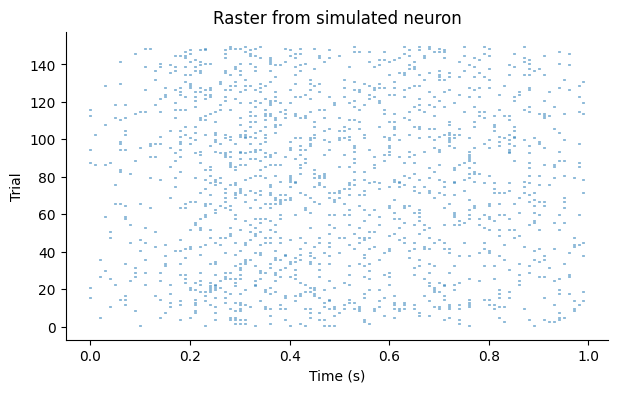

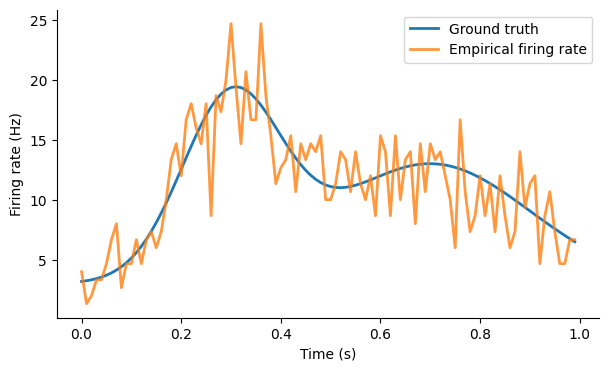

In [ ]:
plt.figure()
for i in range(n_trials):
    spike_times = t[spike_binary[i] == 1]
    plt.vlines(spike_times, i + 0.5, i + 1, linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.title('Raster from simulated neuron')
plt.show()

plt.figure()
plt.plot(t, true_rate, linewidth=2, label='Ground truth')
plt.plot(t, mean_rate_empirical, linewidth=2, alpha=0.8, label='Empirical firing rate')
plt.xlabel('Time (s)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.show()

## 3. Logistic regression on spike train data

Each observation is one time bin from one trial
- Response: `0` or `1`
- Predictor: time within the trial
- Model output: probability of at least one spike in the bin

We use polynomial features of time so the logistic regression can capture a curved relationship.

In [ ]:
# Flatten trial x time into one dataset
X_log_base = np.tile(t, n_trials).reshape(-1, 1)
y_log = spike_binary.reshape(-1)
poly_log = PolynomialFeatures(degree=10, include_bias=False)
X_log = poly_log.fit_transform(X_log_base)
xgrid_log_base = np.linspace(t.min(), t.max(), 200).reshape(-1, 1)
xgrid_log = poly_log.transform(xgrid_log_base)

In [ ]:
def fit_predict_logistic(X, y, xgrid):
    model = LogisticRegression(max_iter=2000)
    model.fit(X, y)
    return model.predict_proba(xgrid)[:, 1]

# # Fit without bootstrapping
# log_model = LogisticRegression(max_iter=2000)
# log_model.fit(X_log, y_log)
# log_pred_grid = log_model.predict_proba(xgrid_log)[:, 1]

# Fit with bootstrapping
log_preds, log_lo, log_med, log_hi = bootstrap_curve(X_log, y_log, xgrid_log, fit_predict_logistic, n_boot=100, seed=2)

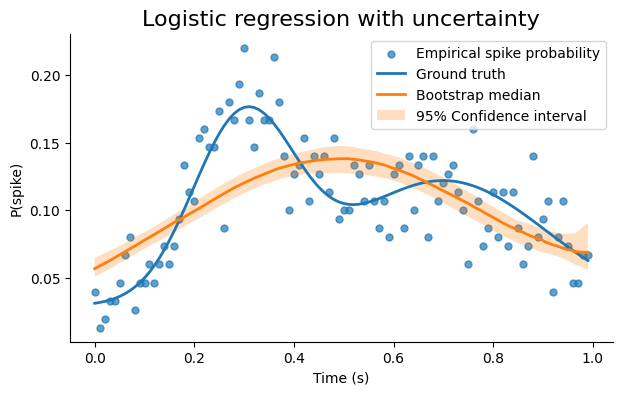

In [ ]:
plt.figure()
plt.scatter(t, emp_spike_prob, s=25, alpha=0.7, label='Empirical spike probability')
plt.plot(t, true_spike_prob, linewidth=2, label='Ground truth')
plt.plot(xgrid_log_base, log_med, linewidth=2, label='Bootstrap median')
plt.fill_between(xgrid_log_base.ravel(), log_lo, log_hi, alpha=0.25, label='95% Confidence interval')
plt.xlabel('Time (s)')
plt.ylabel('P(spike)')
plt.title('Logistic regression with uncertainty', fontsize=16)
plt.legend()
plt.show()

## 4. Poisson GLM on spike train data

Each observation is one time bin from one trial
- Response: spike count in the bin
- Predictor: time within trial
- Output: expected spike count per bin

After fitting, remember to divide the predicted count by `dt` to convert back to firing rate for plotting.

In [ ]:
X_pois_base = np.tile(t, n_trials).reshape(-1, 1)
y_pois = spike_counts.reshape(-1)
poly_pois = PolynomialFeatures(degree=10, include_bias=False)
X_pois = poly_pois.fit_transform(X_pois_base)
xgrid_pois_base = np.linspace(t.min(), t.max(), 200).reshape(-1, 1)
xgrid_pois = poly_pois.transform(xgrid_pois_base)

In [ ]:
def fit_predict_poisson(X, y, xgrid):
    model = PoissonRegressor(alpha=0, max_iter=1000)
    model.fit(X, y)
    pred_counts = model.predict(xgrid)
    return pred_counts / dt

# # Fit once
# pois_model = PoissonRegressor(alpha=0.0, max_iter=1000)
# pois_model.fit(X_pois, y_pois)
# pois_pred_grid = pois_model.predict(xgrid_pois) / dt

# Bootstrap
pois_preds, pois_lo, pois_med, pois_hi = bootstrap_curve(X_pois, y_pois, xgrid_pois, fit_predict_poisson, n_boot=100, seed=3)

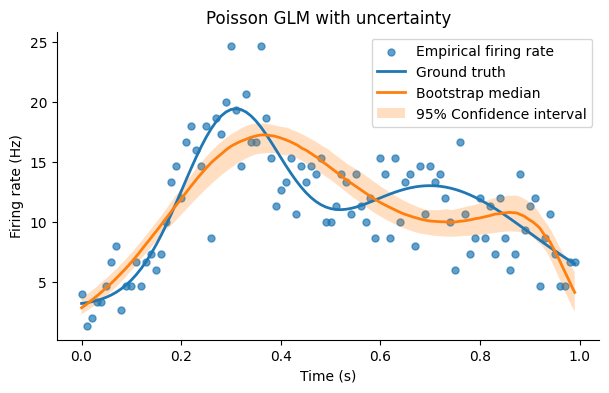

In [ ]:
plt.figure()
plt.scatter(t, mean_rate_empirical, s=25, alpha=0.7, label='Empirical firing rate')
plt.plot(t, true_rate, linewidth=2, label='Ground truth')
plt.plot(xgrid_pois_base, pois_med, linewidth=2, label='Bootstrap median')
plt.fill_between(xgrid_pois_base.flatten(), pois_lo, pois_hi, alpha=0.25, label='95% Confidence interval')
plt.xlabel('Time (s)')
plt.ylabel('Firing rate (Hz)')
plt.title('Poisson GLM with uncertainty')
plt.legend()
plt.show()

## 5. Individual bootstrap Poisson fits

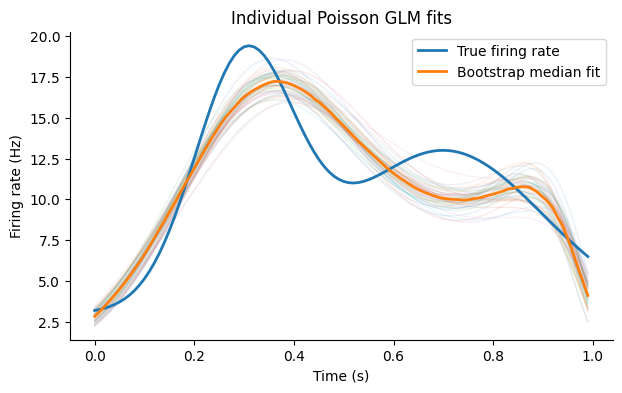

In [ ]:
plt.figure()
for i in range(50):
    plt.plot(xgrid_pois_base, pois_preds[i], alpha=0.1, linewidth=1)
plt.plot(t, true_rate, linewidth=2, label='True firing rate')
plt.plot(xgrid_pois_base, pois_med, linewidth=2, label='Bootstrap median fit')
plt.xlabel('Time (s)')
plt.ylabel('Firing rate (Hz)')
plt.title('Individual Poisson GLM fits')
plt.legend()
plt.show()

## 6. Compare models

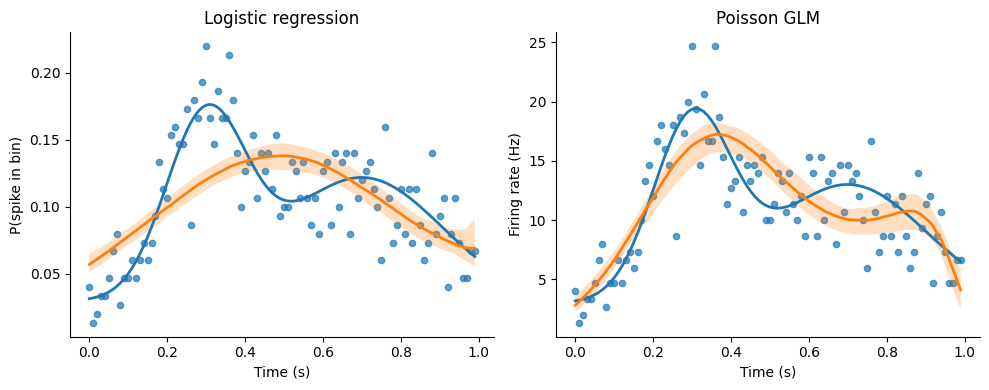

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Logistic regression
axes[0].scatter(t, emp_spike_prob, s=20, alpha=0.7)
axes[0].plot(t, true_spike_prob, linewidth=2, label='True probability')
axes[0].plot(xgrid_log_base, log_med, linewidth=2, label='Median fit')
axes[0].fill_between(xgrid_log_base.ravel(), log_lo, log_hi, alpha=0.25)
axes[0].set_title('Logistic regression')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('P(spike in bin)')

# Poisson GLM
axes[1].scatter(t, mean_rate_empirical, s=20, alpha=0.7)
axes[1].plot(t, true_rate, linewidth=2, label='True rate')
axes[1].plot(xgrid_pois_base, pois_med, linewidth=2, label='Median fit')
axes[1].fill_between(xgrid_pois_base.ravel(), pois_lo, pois_hi, alpha=0.25)
axes[1].set_title('Poisson GLM')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Firing rate (Hz)')

plt.tight_layout()
plt.show()

## 7. Parameter distributions for the Poisson GLM

It can be helpful to look at **parameter uncertainty** in addition to uncertainty in the model predicted curves.

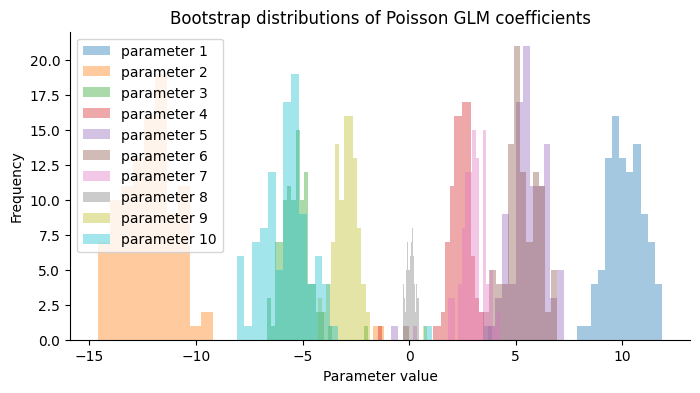

In [ ]:
coef_samples = []
rng_coef = np.random.default_rng(4)

for _ in range(100):
    idx = rng_coef.integers(0, len(y_pois), size=len(y_pois))
    Xb = X_pois[idx]
    yb = y_pois[idx]
    model = PoissonRegressor(alpha=0, max_iter=1000)
    model.fit(Xb, yb)
    coef_samples.append(model.coef_)
coef_samples = np.asarray(coef_samples)

plt.figure(figsize=(8, 4))
for k in range(coef_samples.shape[1]):
    plt.hist(coef_samples[:, k], bins=25, alpha=0.4, label=f'parameter {k+1}')

plt.xlabel('Parameter value')
plt.ylabel('Frequency')
plt.title('Bootstrap distributions of Poisson GLM coefficients')
plt.legend()
plt.show()